#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN                                                                        
**Assignment:** 1 -> KNN.ipynb                                                                      
***Date:*** 14/02/2026

#**1: Download the Dataset**
The dataset is not present in the directory.So I run the shell script get_datasets.sh to fetch the CIFAR-10 data from the web and extract it into the correct folder.

In [8]:
# Move into the dataset directory
%cd cs231n/datasets/

# Download the data
!bash get_datasets.sh

# Move back to the main assignment folder
%cd ../../

/content/drive/MyDrive/assignment1/cs231n/datasets
/content/drive/MyDrive/assignment1


#**2:Loading and Flattening the Data**
Now that the dataset is downloaded, load the raw pixel data. Each image is a 32x32x3 array; I flatten these into a single row of 3,072 values so they can be processed by the kNN classifier.

In [9]:
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# Set the path to the data we just downloaded
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Load raw CIFAR-10
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# Subsample the data
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# Reshape (flatten)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)

Training data shape:  (5000, 3072)
Test data shape:  (500, 3072)


#** 3:Computing the Distance Matrix (Two Loops)**
Now I use our implementation in k_nearest_neighbor.py to compute the Euclidean distance between every test point and every training point. This creates a 500x5000 matrix where dists[i, j] is the distance between the $i$-th test image and $j$-th training image.

Distance matrix shape: (500, 5000)


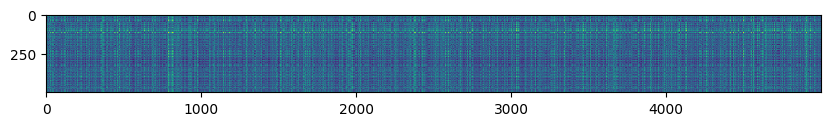

In [10]:
from cs231n.classifiers import KNearestNeighbor

# Create and train
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

# Compute distances using the naive two-loop method
dists = classifier.compute_distances_two_loops(X_test)

# Show the results
print("Distance matrix shape:", dists.shape)
plt.imshow(dists, interpolation='none')
plt.show()

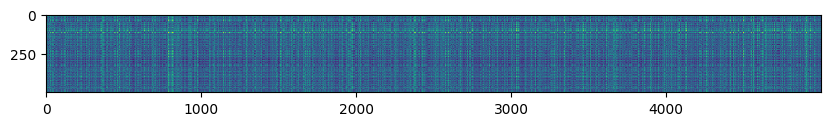

In [11]:
# Compute distances using the two-loop implementation you pasted in k_nearest_neighbor.py
dists = classifier.compute_distances_two_loops(X_test)

# Visualize the matrix
plt.imshow(dists, interpolation='none')
plt.show()


#**Inline Question 1**

###**Patterns in the Matrix**
Notice the structured patterns in the distance matrix, where some rows or columns are visibly brighter.

###**Answer:**

**Bright Rows:** A bright row indicates a test image that is very far from almost all training images. This usually happens if the test image has a very different background or color distribution compared to the training set.

**Bright Columns:** A bright column indicates a training image that is very different from almost all test images. This training point might be an outlier in the dataset.

#**Predicting Labels**
Predicting Labels with $k=1$We implement the predict_labels function logic to find the single nearest neighbor for each test image and assign its label to the test image. We expect an accuracy of around 27%.

In [12]:
# Now implement predict_labels in your .py file and run this:
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


In [13]:
# Now k=5
y_test_pred = classifier.predict_labels(dists, k=5)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


#**Inline Question 2**
###**Preprocessing and L1 Distance Analysis**

I am analyzing how different data preprocessing steps impact the performance of a k-NN classifier using the L1 distance metric. I evaluate whether these transformations change the relative ordering of distances between images.

$\color{blue}{\textit Answer:}$ 1, 2, 3

$\color{blue}{\textit  Explanation:}$
>**1 & 2 (Mean Subtraction):** Subtracting a constant value (the global mean or per-pixel mean) from all pixel values does not change the L1 distance. Since $|(x-c) - (y-c)| = |x-y|$, the distance between any two images remains the same, so the nearest neighbors do not change.

>**3 (Global Scaling):** Dividing by the global standard deviation $\sigma$ scales all L1 distances by the same factor $1/\sigma$. Although the absolute values of the distances change, their relative order remains identical, so the classification results do not change.

>**4 (Per-pixel Scaling):** This will change performance. Dividing each pixel by its own standard deviation weights different features (pixels) differently, which can change which training image is considered "closest" to a test image.

>**5 (Rotation):** L1 distance is not rotationally invariant. Rotating the coordinate axes changes the L1 distance between points, which can lead to different classification results.



###**Partial Vectorization (One Loop)**
Instead of looping over every training image for every test image, we vectorize the operation for each test image, computing its distance to all training images at once using NumPy.

In [14]:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure correctness, we check the Frobenius norm difference
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


###**Full Vectorization (No Loops)**
We implement the distance calculation using only matrix operations. This is significantly faster as it avoids all Python-level loops and relies entirely on optimized BLAS libraries.

In [16]:
dists_two = classifier.compute_distances_no_loops(X_test)

# Check that it matches the original
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


###**Comparing Execution Time**
We measure the time taken by each of the three implementations.I notice a massive decrease in time as we move from nested loops to full vectorization, highlighting why NumPy operations are preferred in machine learning.

In [17]:
def time_function(f, *args):
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

Two loop version took 35.976804 seconds
One loop version took 48.170185 seconds
No loop version took 0.528703 seconds


#**Cross-Validation**
###**Hyperparameter Tuning via Cross-Validation**

I am performing 5-fold cross-validation to determine the optimal value of $k$. I split the training data into folds and iteratively use each fold as a validation set while training on the remaining four, ensuring that the chosen $k$ generalizes well to new data.

In [18]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

# I split the training data and labels into folds
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds):
        # I create the training set by combining all folds except the i-th fold
        X_train_cv = np.vstack(X_train_folds[:i] + X_train_folds[i+1:])
        y_train_cv = np.concatenate(y_train_folds[:i] + y_train_folds[i+1:])

        # I use the i-th fold as the validation set
        X_val_cv = X_train_folds[i]
        y_val_cv = y_train_folds[i]

        # I initialize the classifier and train it
        classifier.train(X_train_cv, y_train_cv)

        # I compute distances using the efficient no-loop version
        dists_cv = classifier.compute_distances_no_loops(X_val_cv)

        # I predict the labels for the validation set
        y_val_pred = classifier.predict_labels(dists_cv, k=k)

        # I calculate accuracy and store it
        accuracy = np.mean(y_val_pred == y_val_cv)
        k_to_accuracies[k].append(accuracy)

# I print out the computed accuracies for each k
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

###**Visualizing Cross-Validation and Final Testing**
I am plotting the accuracy for each value of $k$ across all folds to identify the trend and choose the best performing hyperparameter. After selecting the optimal $k$, I retrain the classifier on the full training set and evaluate its final accuracy on the test data.

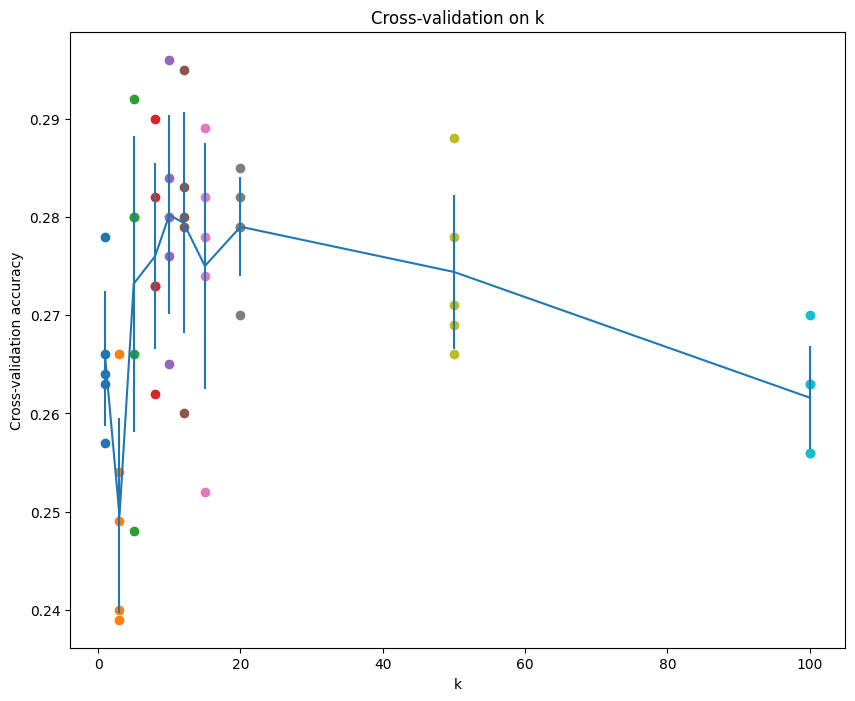

Got 141 / 500 correct => accuracy: 0.282000


In [19]:
# I plot the raw observations for each k
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# I plot the trend line with error bars corresponding to the standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

# Based on the plot, I choose the best_k (e.g., 10 or 8 often perform well)
# I will set it to 10 here, but you should pick the k with the highest mean accuracy
best_k = 10

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# I compute and display the final accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

#**Inline Question 3**


###**Evaluating k-NN Theory**

I am identifying the core properties of the k-Nearest Neighbor algorithm, specifically focusing on its decision boundaries, error behavior on training versus test data, and its computational scaling.

**$\color{blue}{\textit  Answer:}$** 2 and 4  

**$\color{blue}{\textit Explanation:}$**

**Statement 2 is True**:

For a 1-NN classifier, the training error is always zero because the nearest neighbor to any training point is the point itself. In contrast, a 5-NN classifier could misclassify a training point if the majority of its five nearest neighbors belong to a different class. Therefore, the error of 1-NN (0) is always less than or equal to the error of 5-NN.

**Statement 4 is True:**

 k-NN is a *lazy learner*. The model performs no real work during training and instead compares each test example to every training example during inference. As a result, classification time increases linearly with the number of training examples ($O(N)$).

**Statement 1 is False:**

The decision boundary of k-NN is not a straight line. It is locally linear but globally complex and jagged, following the Voronoi tessellation created by the training data.

**Statement 3 is False**:

1-NN is highly sensitive to noise and outliers, which often leads to overfitting. Increasing $k$ smooths the decision boundary and typically produces lower test error and better generalization.
